# Project 1: MNIST Image Denoising Using an Autoencoder

This notebook builds a denoising autoencoder that learns to remove artificial noise from MNIST digit images. Noisy images are used as model inputs, and the original clean images are used as reconstruction targets.

## 1. Import Libraries and Set Configuration

In [1]:
from pathlib import Path
import random
import csv

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import tensorflow as tf
from tensorflow.keras import layers, models

%matplotlib inline

SEED = 42
NOISE_FACTOR = 0.5
TRAIN_LIMIT = 2000   # Set to 0 to use all training images
TEST_LIMIT = 500     # Set to 0 to use all test images
EPOCHS = 5
BATCH_SIZE = 128

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

candidate_data_dirs = [Path('mnist_png'), Path('../mnist_png')]
DATA_DIR = next((path for path in candidate_data_dirs if path.exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError('Could not find mnist_png. Keep it beside this notebook folder or in the project root.')

OUTPUT_DIR = Path('outputs') / 'mnist_denoising_autoencoder'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('TensorFlow version:', tf.__version__)
print('Dataset path:', DATA_DIR.resolve())
print('Output path:', OUTPUT_DIR.resolve())

TensorFlow version: 2.21.0
Dataset path: C:\Users\abhil\Desktop\Celebal\mnist_png
Output path: C:\Users\abhil\Desktop\Celebal\outputs\mnist_denoising_autoencoder


## 2. Load and Preprocess the MNIST Dataset

The images are loaded from the local `mnist_png` folders, converted to grayscale, resized to `28 x 28`, normalized to `[0, 1]`, and reshaped to `(28, 28, 1)`.

In [2]:
IMAGE_SHAPE = (28, 28, 1)

def collect_image_paths(split_dir, limit=0, seed=42):
    paths = sorted(split_dir.glob('*/*.png'))
    if not paths:
        raise FileNotFoundError(f'No PNG files found in {split_dir}')
    if limit and limit < len(paths):
        rng = random.Random(seed)
        paths = rng.sample(paths, limit)
        paths.sort()
    return paths

def load_png_images(split_dir, limit=0, seed=42):
    paths = collect_image_paths(split_dir, limit, seed)
    images = np.empty((len(paths), *IMAGE_SHAPE), dtype=np.float32)
    labels = np.empty((len(paths),), dtype=np.int64)

    for index, image_path in enumerate(paths):
        with Image.open(image_path) as img:
            gray = img.convert('L').resize((28, 28))
            images[index, :, :, 0] = np.asarray(gray, dtype=np.float32) / 255.0
        labels[index] = int(image_path.parent.name)

    return images, labels

x_train, y_train = load_png_images(DATA_DIR / 'training', TRAIN_LIMIT, SEED)
x_test, y_test = load_png_images(DATA_DIR / 'testing', TEST_LIMIT, SEED + 1)

print('Training data:', x_train.shape)
print('Testing data:', x_test.shape)
print('Pixel range:', x_train.min(), 'to', x_train.max())

Training data: (2000, 28, 28, 1)
Testing data: (500, 28, 28, 1)
Pixel range: 0.0 to 1.0


## 3. Add Artificial Noise

Gaussian noise is added to create noisy input images. Pixel values are clipped so they remain valid grayscale values.

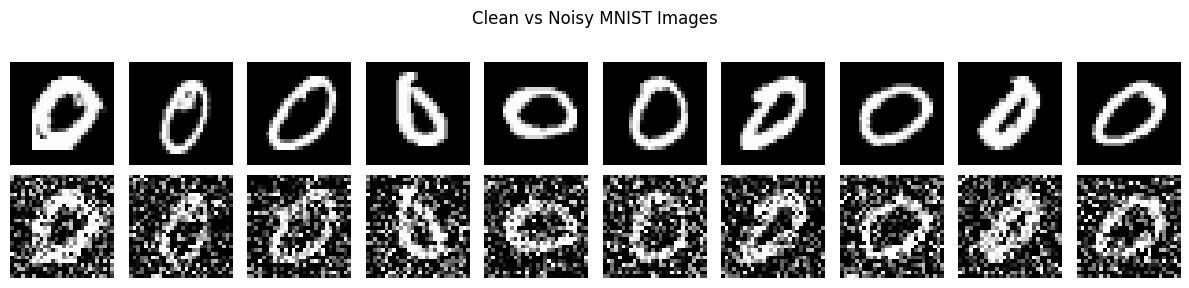

In [3]:
def add_gaussian_noise(images, noise_factor=0.5, seed=42):
    rng = np.random.default_rng(seed)
    noise = rng.normal(loc=0.0, scale=1.0, size=images.shape).astype(np.float32)
    noisy_images = images + noise_factor * noise
    return np.clip(noisy_images, 0.0, 1.0)

x_train_noisy = add_gaussian_noise(x_train, NOISE_FACTOR, SEED + 2)
x_test_noisy = add_gaussian_noise(x_test, NOISE_FACTOR, SEED + 3)

fig, axes = plt.subplots(2, 10, figsize=(12, 3))
for i in range(10):
    axes[0, i].imshow(x_train[i].squeeze(), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(x_train_noisy[i].squeeze(), cmap='gray')
    axes[1, i].axis('off')
axes[0, 0].set_ylabel('Clean')
axes[1, 0].set_ylabel('Noisy')
plt.suptitle('Clean vs Noisy MNIST Images')
plt.tight_layout()
plt.show()

## 4. Build the Denoising Autoencoder

The encoder compresses the noisy image into feature maps. The decoder reconstructs the clean digit from this compressed representation.

In [4]:
def build_autoencoder():
    inputs = layers.Input(shape=IMAGE_SHAPE, name='noisy_image')

    encoded = layers.Conv2D(32, 3, activation='relu', padding='same')(inputs)
    encoded = layers.MaxPooling2D(2, padding='same')(encoded)
    encoded = layers.Conv2D(64, 3, activation='relu', padding='same')(encoded)
    encoded = layers.MaxPooling2D(2, padding='same', name='encoded_features')(encoded)

    decoded = layers.Conv2D(64, 3, activation='relu', padding='same')(encoded)
    decoded = layers.UpSampling2D(2)(decoded)
    decoded = layers.Conv2D(32, 3, activation='relu', padding='same')(decoded)
    decoded = layers.UpSampling2D(2)(decoded)
    outputs = layers.Conv2D(1, 3, activation='sigmoid', padding='same')(decoded)

    model = models.Model(inputs, outputs, name='mnist_denoising_autoencoder')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['mse'],
    )
    return model

autoencoder = build_autoencoder()
autoencoder.summary()

Model: "mnist_denoising_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ noisy_image (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded_features (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Train the Model

The model is trained with noisy images as input and clean images as the target output.

In [5]:
history = autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_split=0.1,
    verbose=2,
)

Epoch 1/5
15/15 - 7s - 490ms/step - loss: 0.5275 - mse: 0.1460 - val_loss: 0.4215 - val_mse: 0.1054
Epoch 2/5
15/15 - 2s - 107ms/step - loss: 0.3564 - mse: 0.0885 - val_loss: 0.2361 - val_mse: 0.0553
Epoch 3/5
15/15 - 3s - 170ms/step - loss: 0.2277 - mse: 0.0553 - val_loss: 0.1938 - val_mse: 0.0451
Epoch 4/5
15/15 - 3s - 173ms/step - loss: 0.1926 - mse: 0.0435 - val_loss: 0.1779 - val_mse: 0.0394
Epoch 5/5
15/15 - 2s - 106ms/step - loss: 0.1714 - mse: 0.0363 - val_loss: 0.1655 - val_mse: 0.0350


## 6. Plot Training History

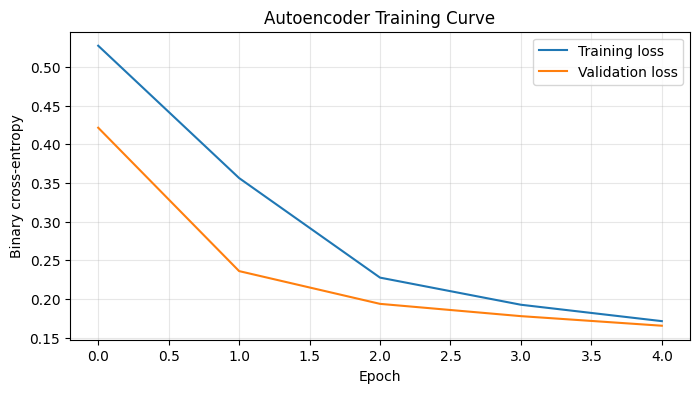

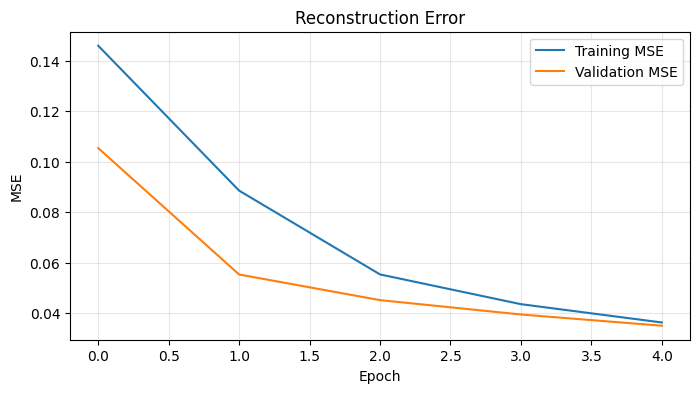

In [6]:
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Binary cross-entropy')
plt.title('Autoencoder Training Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history.history['mse'], label='Training MSE')
plt.plot(history.history['val_mse'], label='Validation MSE')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('Reconstruction Error')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 7. Generate Denoised Outputs on the Test Set

In [7]:
denoised_images = autoencoder.predict(x_test_noisy, batch_size=BATCH_SIZE, verbose=0)
print('Denoised output shape:', denoised_images.shape)

Denoised output shape: (500, 28, 28, 1)


## 8. Visualize Original, Noisy, and Reconstructed Images

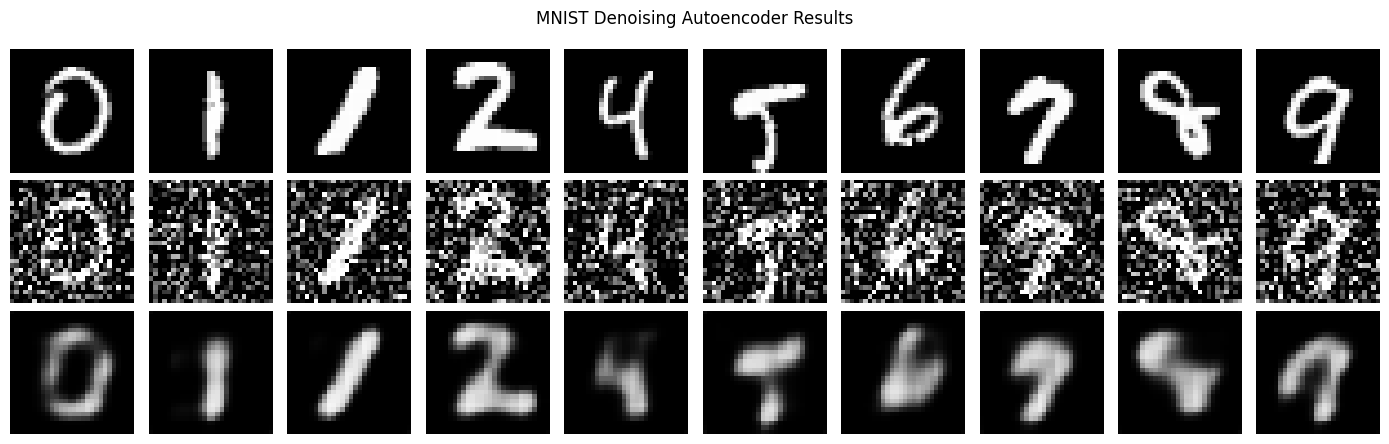

Saved comparison image to: outputs\mnist_denoising_autoencoder\denoising_comparison.png


In [8]:
sample_count = 10
sample_indices = np.linspace(0, len(x_test) - 1, sample_count, dtype=int)

fig, axes = plt.subplots(3, sample_count, figsize=(14, 4.5))
row_titles = ['Original', 'Noisy', 'Denoised']

for row, images in enumerate([x_test, x_test_noisy, denoised_images]):
    for col, sample_index in enumerate(sample_indices):
        axes[row, col].imshow(images[sample_index].squeeze(), cmap='gray', vmin=0, vmax=1)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(row_titles[row], fontsize=11)

plt.suptitle('MNIST Denoising Autoencoder Results')
plt.tight_layout()
comparison_path = OUTPUT_DIR / 'denoising_comparison.png'
plt.savefig(comparison_path, dpi=180)
plt.show()

print('Saved comparison image to:', comparison_path)

## 9. Evaluate Denoising Performance

MSE measures pixel-level reconstruction error. PSNR and SSIM provide additional image-quality comparisons.

In [9]:
def mean_squared_error(reference, estimate):
    return float(np.mean(np.square(reference - estimate)))

def peak_signal_to_noise_ratio(reference, estimate):
    mse = mean_squared_error(reference, estimate)
    if mse == 0:
        return float('inf')
    return float(20.0 * np.log10(1.0 / np.sqrt(mse)))

def structural_similarity(reference, estimate):
    scores = tf.image.ssim(
        tf.convert_to_tensor(reference, dtype=tf.float32),
        tf.convert_to_tensor(estimate, dtype=tf.float32),
        max_val=1.0,
    )
    return float(tf.reduce_mean(scores).numpy())

noisy_mse = mean_squared_error(x_test, x_test_noisy)
denoised_mse = mean_squared_error(x_test, denoised_images)

metrics = {
    'noise_factor': NOISE_FACTOR,
    'noisy_mse': noisy_mse,
    'denoised_mse': denoised_mse,
    'mse_reduction_percent': 100.0 * (noisy_mse - denoised_mse) / noisy_mse,
    'noisy_psnr': peak_signal_to_noise_ratio(x_test, x_test_noisy),
    'denoised_psnr': peak_signal_to_noise_ratio(x_test, denoised_images),
    'noisy_ssim': structural_similarity(x_test, x_test_noisy),
    'denoised_ssim': structural_similarity(x_test, denoised_images),
}

for metric, value in metrics.items():
    print(f'{metric}: {value:.4f}')

noise_factor: 0.5000
noisy_mse: 0.1159
denoised_mse: 0.0320
mse_reduction_percent: 72.3730
noisy_psnr: 9.3604
denoised_psnr: 14.9471
noisy_ssim: 0.4026
denoised_ssim: 0.5506


## 10. Save Model, Metrics, and Results

In [10]:
model_path = OUTPUT_DIR / 'mnist_denoising_autoencoder.keras'
metrics_path = OUTPUT_DIR / 'denoising_metrics.csv'
history_path = OUTPUT_DIR / 'training_history.csv'
samples_path = OUTPUT_DIR / 'denoised_test_samples.npy'

autoencoder.save(model_path)
np.save(samples_path, denoised_images[:100])

with metrics_path.open('w', newline='', encoding='utf-8') as file:
    writer = csv.writer(file)
    writer.writerow(['metric', 'value'])
    for key, value in metrics.items():
        writer.writerow([key, value])

history_keys = list(history.history.keys())
with history_path.open('w', newline='', encoding='utf-8') as file:
    writer = csv.writer(file)
    writer.writerow(['epoch', *history_keys])
    for epoch in range(len(history.history[history_keys[0]])):
        writer.writerow([epoch + 1, *[history.history[key][epoch] for key in history_keys]])

print('Saved model:', model_path)
print('Saved metrics:', metrics_path)
print('Saved history:', history_path)
print('Saved samples:', samples_path)

Saved model: outputs\mnist_denoising_autoencoder\mnist_denoising_autoencoder.keras
Saved metrics: outputs\mnist_denoising_autoencoder\denoising_metrics.csv
Saved history: outputs\mnist_denoising_autoencoder\training_history.csv
Saved samples: outputs\mnist_denoising_autoencoder\denoised_test_samples.npy


## Observations and Analysis

The model learns to map noisy handwritten digits back to cleaner digit images. The noisy inputs contain strong random pixel-level disturbances, but the reconstructed outputs usually recover the main digit structure and remove much of the background noise.

A key observation is that denoised images can look smoother than the original images. This happens because the encoder compresses the image into a smaller representation, so the decoder reconstructs the most likely digit pattern while losing some fine details.

The model performs well for moderate Gaussian noise. If the noise factor is increased too much, thin strokes and digit boundaries become harder to reconstruct. Better results can be achieved by training for more epochs, using the full MNIST training set, or experimenting with deeper encoder-decoder architectures.